# **PHÂN TÍCH COHORT ANALYSIS**

## 1. Chuẩn bị

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt


In [3]:
#df_customers = pd.read_csv("/content/drive/MyDrive/Project-Based/Buổi 6: Cohort Analysis/Customer.csv")
df_sales = pd.read_csv("/content/drive/MyDrive/Project-Based/Buổi 6: Cohort Analysis/EcomSales.csv")
#df_products = pd.read_csv("/content/drive/MyDrive/Project-Based/Buổi 6: Cohort Analysis/Product.csv")
#df_region = pd.read_csv("/content/drive/MyDrive/Project-Based/Buổi 6: Cohort Analysis/Region.csv")
df_sales.head()

,RowID,OrderID,OrderDate,CustomerID,Segment,RegionCode,ProductCode,Quantity,Sales,Discount,Profit
0,25221,IN-2012-TH211151-41003,4/4/2020,TH-211151,Corporate,RRR0001,P000001,13,416,0.0,208.0
1,29464,ID-2013-BD116051-41518,9/1/2021,BD-116051,Consumer,R0002,PPP000002,4,20,0.0,10.0
2,27311,IN-2015-TS212051-42173,6/18/2023,TS-212051,Corporate,R0003,P000003,2,20,0.0,8.0
3,28882,IN-2014-SU206651-41899,9/17/2022,SU-206651,Self-Employed,R0003,P000004,4,556,0.0,55.6
4,27992,IN-2015-GM144551-42217,8/1/2023,GM-144551,Self-Employed,R0003,P000005,2,6,0.0,0.6


In [5]:
df = df_sales[['CustomerID', 'OrderDate']].drop_duplicates(ignore_index=True)
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df.head()


,CustomerID,OrderDate
0,TH-211151,2020-04-04
1,BD-116051,2021-09-01
2,TS-212051,2023-06-18
3,SU-206651,2022-09-17
4,GM-144551,2023-08-01


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25719 entries, 0 to 25718
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   CustomerID  25719 non-null  object        
 1   OrderDate   25719 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(1)
memory usage: 402.0+ KB


In [8]:
df_first_purchase = df.groupby('CustomerID')['OrderDate'].min().reset_index()
df_first_purchase.columns = ['CustomerID', 'FirstPurchaseDate']
df_first_purchase['FirstMonth'] = df_first_purchase['FirstPurchaseDate'].dt.strftime('%Y-%m')
df_first_purchase.head()

,CustomerID,FirstPurchaseDate,FirstMonth
0,AA-10315102,2020-07-03,2020-07
1,AA-10315120,2021-05-16,2021-05
2,AA-10315139,2022-09-19,2022-09
3,AA-103151402,2022-03-04,2022-03
4,AA-103151404,2020-03-30,2020-03


In [15]:
df_pre_cohort = df.merge(df_first_purchase, on='CustomerID', how = "inner")
df_pre_cohort['MonthAfter'] = (df_pre_cohort['OrderDate'].dt.month - df_pre_cohort['FirstPurchaseDate'].dt.month) + (df_pre_cohort['OrderDate'].dt.year - df_pre_cohort['FirstPurchaseDate'].dt.year) * 12
df_pre_cohort.head()


,CustomerID,OrderDate,FirstPurchaseDate,FirstMonth,MonthAfter
0,TH-211151,2020-04-04,2020-04-04,2020-04,0
1,BD-116051,2021-09-01,2021-09-01,2021-09,0
2,TS-212051,2023-06-18,2023-06-18,2023-06,0
3,SU-206651,2022-09-17,2022-09-17,2022-09,0
4,GM-144551,2023-08-01,2023-08-01,2023-08,0


In [13]:
df_cohort = df_pre_cohort.pivot_table(index='FirstMonth', columns='MonthAfter', values='CustomerID', aggfunc='nunique')
df_cohort.head()

MonthAfter,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
FirstMonth,,,,,,,,,,,,,,,,,,,,,
2020-01,215.0,NaN,1.0,3.0,2.0,4.0,NaN,7.0,6.0,2.0,...,6.0,3.0,3.0,8.0,3.0,11.0,7.0,10.0,7.0,9.0
2020-02,202.0,1.0,2.0,1.0,3.0,4.0,3.0,6.0,4.0,1.0,...,1.0,10.0,3.0,5.0,6.0,7.0,4.0,5.0,7.0,NaN
2020-03,264.0,5.0,3.0,4.0,5.0,3.0,6.0,3.0,9.0,4.0,...,10.0,10.0,5.0,9.0,13.0,9.0,15.0,7.0,NaN,NaN
2020-04,245.0,2.0,4.0,4.0,2.0,5.0,4.0,8.0,7.0,1.0,...,13.0,4.0,12.0,12.0,6.0,8.0,8.0,NaN,NaN,NaN
2020-05,306.0,4.0,2.0,4.0,5.0,4.0,9.0,5.0,5.0,1.0,...,4.0,10.0,16.0,4.0,13.0,7.0,NaN,NaN,NaN,NaN


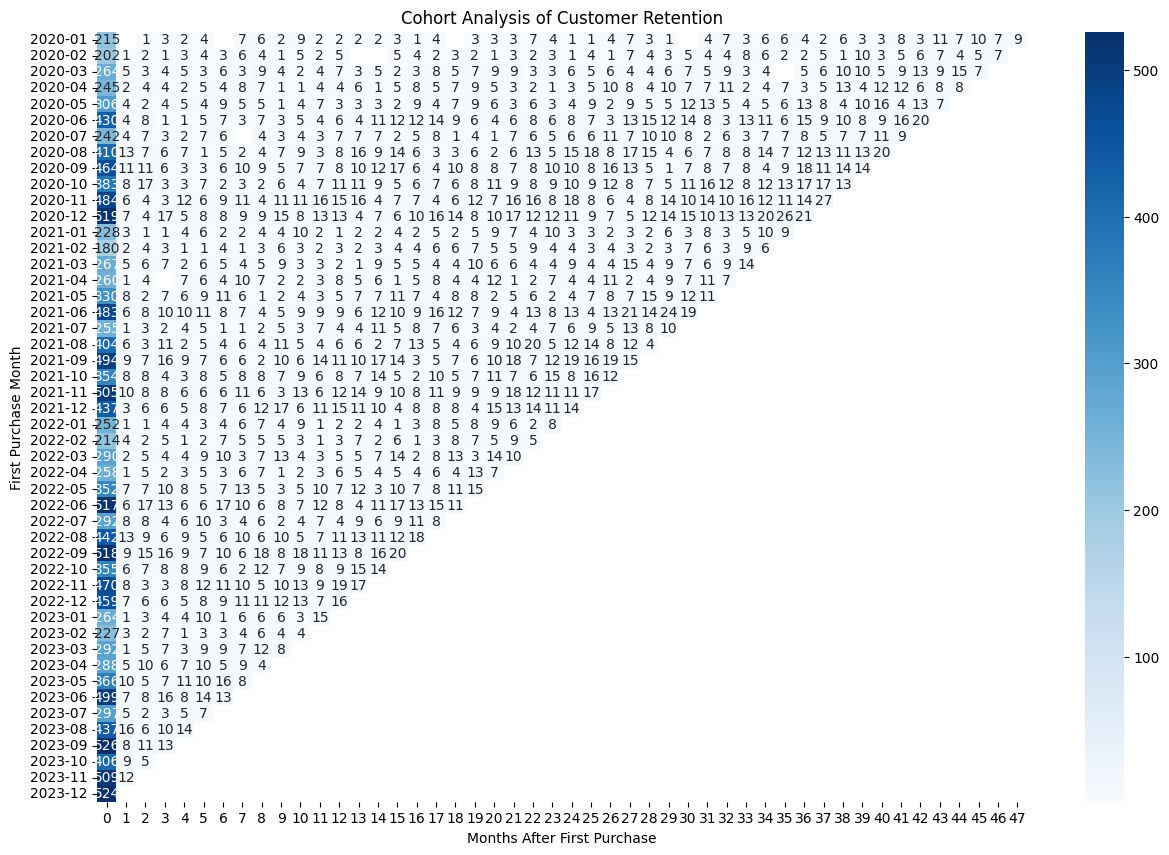

In [19]:
plt.figure(figsize=(15, 10))
sns.heatmap(df_cohort, annot=True, fmt='g', cmap='Blues')
plt.title('Cohort Analysis of Customer Retention')
plt.xlabel('Months After First Purchase')
plt.ylabel('First Purchase Month')
plt.show()

In [18]:
cohort_sizes = df_cohort.iloc[:, 0]
retention_matrix = df_cohort.divide(cohort_sizes, axis=0)
retention_matrix.head()

MonthAfter,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
FirstMonth,,,,,,,,,,,,,,,,,,,,,
2020-01,1.0,NaN,0.004651,0.013953,0.009302,0.018605,NaN,0.032558,0.027907,0.009302,...,0.027907,0.013953,0.013953,0.037209,0.013953,0.051163,0.032558,0.046512,0.032558,0.04186
2020-02,1.0,0.004950,0.009901,0.004950,0.014851,0.019802,0.014851,0.029703,0.019802,0.004950,...,0.004950,0.049505,0.014851,0.024752,0.029703,0.034653,0.019802,0.024752,0.034653,NaN
2020-03,1.0,0.018939,0.011364,0.015152,0.018939,0.011364,0.022727,0.011364,0.034091,0.015152,...,0.037879,0.037879,0.018939,0.034091,0.049242,0.034091,0.056818,0.026515,NaN,NaN
2020-04,1.0,0.008163,0.016327,0.016327,0.008163,0.020408,0.016327,0.032653,0.028571,0.004082,...,0.053061,0.016327,0.048980,0.048980,0.024490,0.032653,0.032653,NaN,NaN,NaN
2020-05,1.0,0.013072,0.006536,0.013072,0.016340,0.013072,0.029412,0.016340,0.016340,0.003268,...,0.013072,0.032680,0.052288,0.013072,0.042484,0.022876,NaN,NaN,NaN,NaN
